# Нейронная сеть — датасет MNIST

Демонстрируется классификация рукописных цифр (0–9)
с помощью `NeuralNetwork` из библиотеки **numl**.

**Архитектура сети:**
```
Вход (784) → Dense(128, ReLU) → Dense(64, ReLU) → Dense(10, Softmax)
```

**Структура ноутбука:**
1. Загрузка и визуализация MNIST  
2. Предобработка  
3. Обучение и кривые потерь / accuracy  
4. Анализ ошибок: матрица ошибок и примеры неверных предсказаний  
5. Влияние размера скрытых слоёв

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

import sys, os
sys.path.insert(0, os.path.abspath(".."))
from numl import MNISTNeuralNetwork

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
np.random.seed(42)

## 1. Загрузка данных

In [8]:
# Загрузка MNIST через sklearn (первый запуск займёт ~1 мин)
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X_raw, y_raw = mnist.data, mnist.target.astype(int)

print(f"Форма X: {X_raw.shape}  |  dtype: {X_raw.dtype}")
print(f"Метки: {np.unique(y_raw)}")

Форма X: (70000, 784)  |  dtype: int64
Метки: [0 1 2 3 4 5 6 7 8 9]


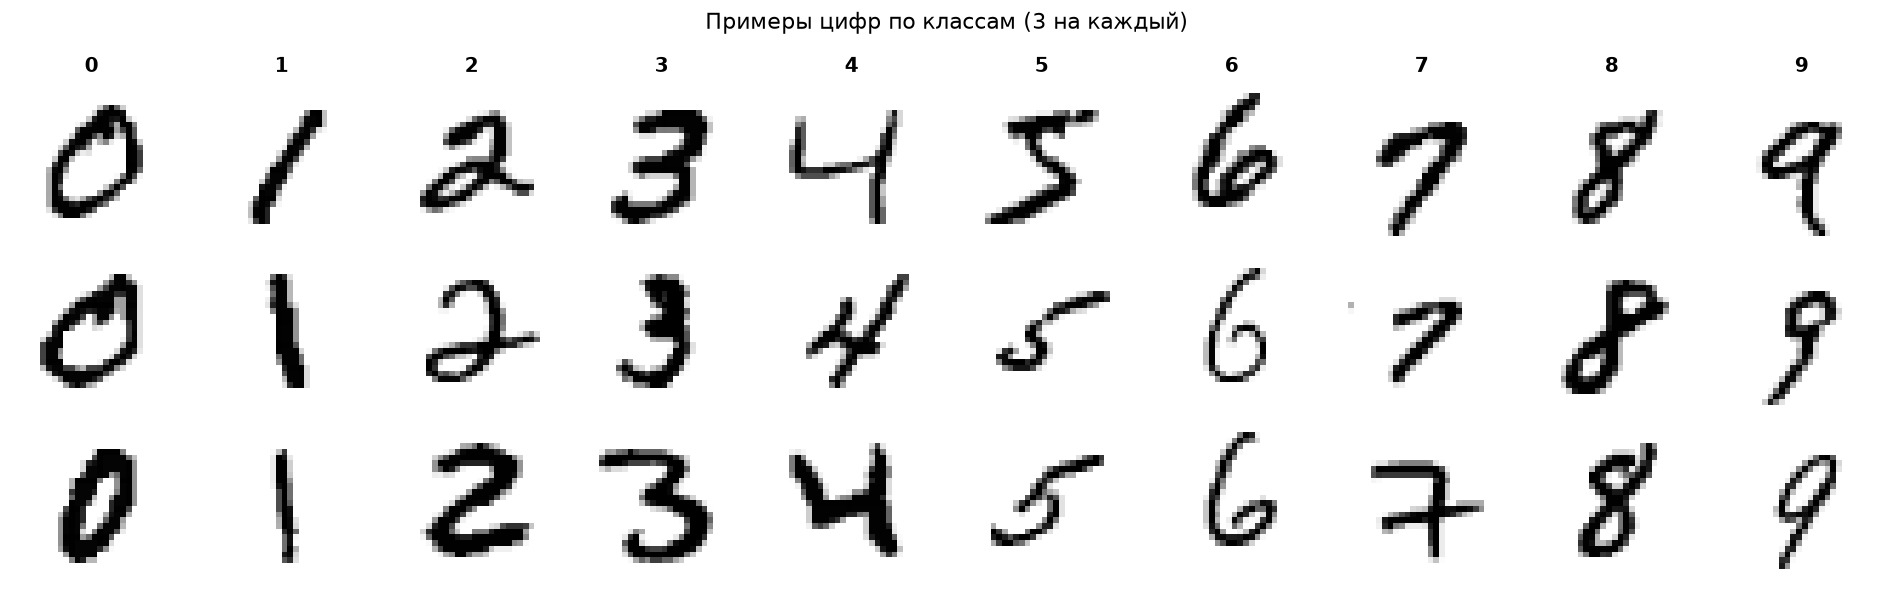

In [9]:
# Визуализация случайных примеров
fig, axes = plt.subplots(3, 10, figsize=(16, 5))
for digit in range(10):
    idxs = np.where(y_raw == digit)[0][:3]
    for row, idx in enumerate(idxs):
        ax = axes[row, digit]
        ax.imshow(X_raw[idx].reshape(28, 28), cmap="gray_r")
        ax.axis("off")
        if row == 0:
            ax.set_title(str(digit), fontsize=12, fontweight="bold")
plt.suptitle("Примеры цифр по классам (3 на каждый)", fontsize=13)
plt.tight_layout()
plt.show()

## 2. Предобработка

In [10]:
# Нормализация в [0, 1] — стандартная практика для изображений
X = X_raw / 255.0

# Стратифицированное разбиение: 60k train / 10k test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_raw, test_size=10000, random_state=42, stratify=y_raw
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Распределение классов (train):")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Цифра {u}: {c} примеров")

Train: (60000, 784)  |  Test: (10000, 784)
Распределение классов (train):
  Цифра 0: 5917 примеров
  Цифра 1: 6752 примеров
  Цифра 2: 5991 примеров
  Цифра 3: 6121 примеров
  Цифра 4: 5849 примеров
  Цифра 5: 5411 примеров
  Цифра 6: 5894 примеров
  Цифра 7: 6251 примеров
  Цифра 8: 5850 примеров
  Цифра 9: 5964 примеров


## 3. Обучение

In [11]:
model = MNISTNeuralNetwork(
    input_size=784,
    hidden1=128,
    hidden2=64,
    output_size=10,
    lr=0.01,
    epochs=20,
    batch_size=64,
)

model.fit(X_train, y_train)

Эпоха   1/20  Loss=0.3839  Accuracy=0.8942
Эпоха   2/20  Loss=0.2989  Accuracy=0.9148
Эпоха   3/20  Loss=0.2574  Accuracy=0.9280
Эпоха   4/20  Loss=0.2344  Accuracy=0.9340
Эпоха   5/20  Loss=0.2145  Accuracy=0.9398
Эпоха   6/20  Loss=0.2002  Accuracy=0.9432
Эпоха   7/20  Loss=0.1841  Accuracy=0.9480
Эпоха   8/20  Loss=0.1738  Accuracy=0.9510
Эпоха   9/20  Loss=0.1637  Accuracy=0.9540
Эпоха  10/20  Loss=0.1544  Accuracy=0.9565
Эпоха  11/20  Loss=0.1481  Accuracy=0.9582
Эпоха  12/20  Loss=0.1412  Accuracy=0.9597
Эпоха  13/20  Loss=0.1332  Accuracy=0.9623
Эпоха  14/20  Loss=0.1285  Accuracy=0.9642
Эпоха  15/20  Loss=0.1228  Accuracy=0.9653
Эпоха  16/20  Loss=0.1181  Accuracy=0.9664
Эпоха  17/20  Loss=0.1143  Accuracy=0.9676
Эпоха  18/20  Loss=0.1079  Accuracy=0.9693
Эпоха  19/20  Loss=0.1033  Accuracy=0.9712
Эпоха  20/20  Loss=0.0995  Accuracy=0.9720


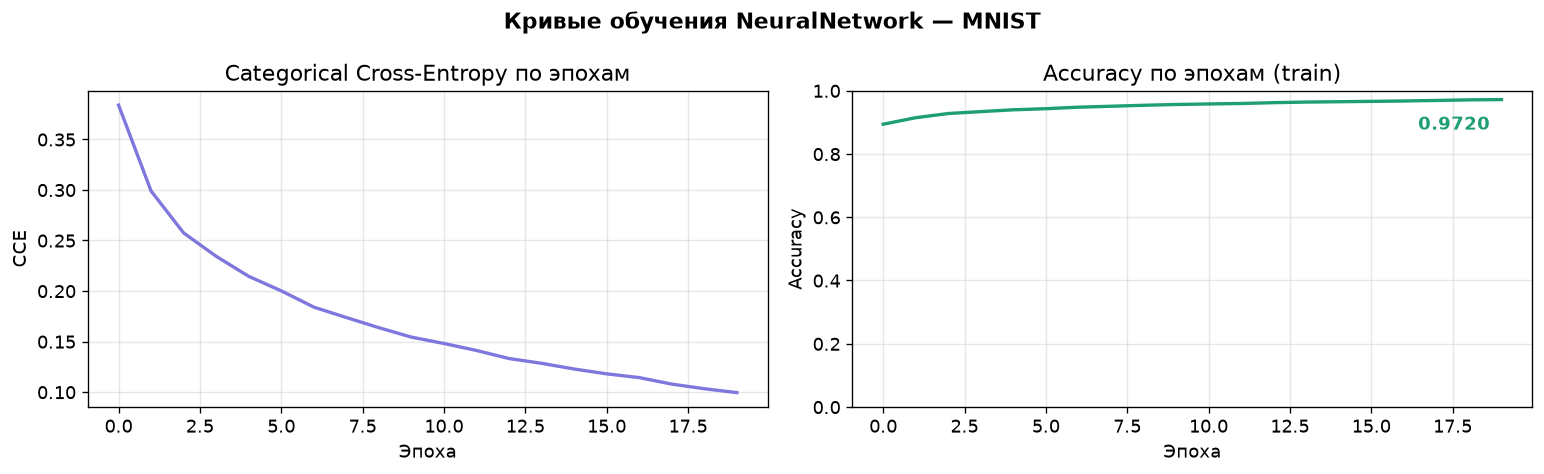

Финальная accuracy на тесте: 0.9641


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(model.loss_history, color="#7F77DD", linewidth=2)
ax1.set_title("Categorical Cross-Entropy по эпохам")
ax1.set_xlabel("Эпоха"); ax1.set_ylabel("CCE")
ax1.grid(True, alpha=0.3)

ax2.plot(model.acc_history, color="#1D9E75", linewidth=2)
ax2.set_ylim(0, 1)
ax2.set_title("Accuracy по эпохам (train)")
ax2.set_xlabel("Эпоха"); ax2.set_ylabel("Accuracy")
ax2.annotate(f"{model.acc_history[-1]:.4f}",
             xy=(len(model.acc_history)-1, model.acc_history[-1]),
             xytext=(-50, -18), textcoords="offset points",
             color="#1D9E75", fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.suptitle("Кривые обучения NeuralNetwork — MNIST", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Финальная accuracy на тесте: {model.score(X_test, y_test):.4f}")

## 4. Анализ ошибок

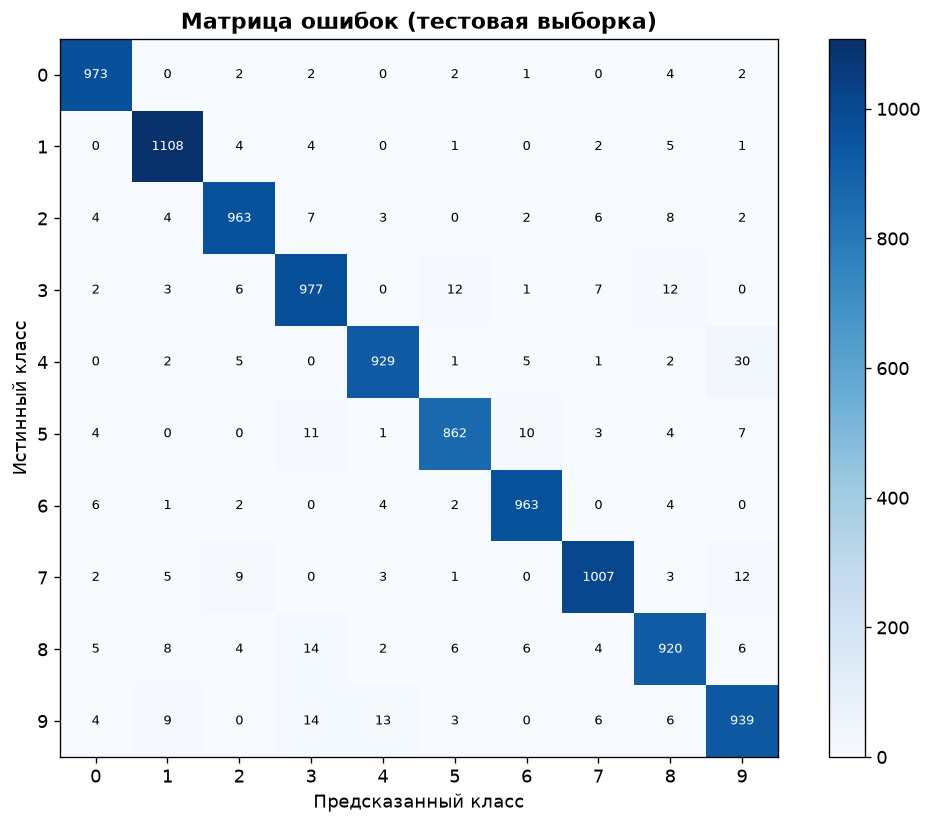

In [13]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
for i in range(10):
    for j in range(10):
        val = cm[i, j]
        ax.text(j, i, val, ha="center", va="center", fontsize=8,
                color="white" if val > cm.max() * 0.5 else "black")
ax.set_xticks(range(10)); ax.set_xticklabels(range(10))
ax.set_yticks(range(10)); ax.set_yticklabels(range(10))
ax.set_xlabel("Предсказанный класс"); ax.set_ylabel("Истинный класс")
ax.set_title("Матрица ошибок (тестовая выборка)", fontweight="bold")
plt.tight_layout()
plt.show()

Всего ошибок: 359 из 10000 (3.6%)


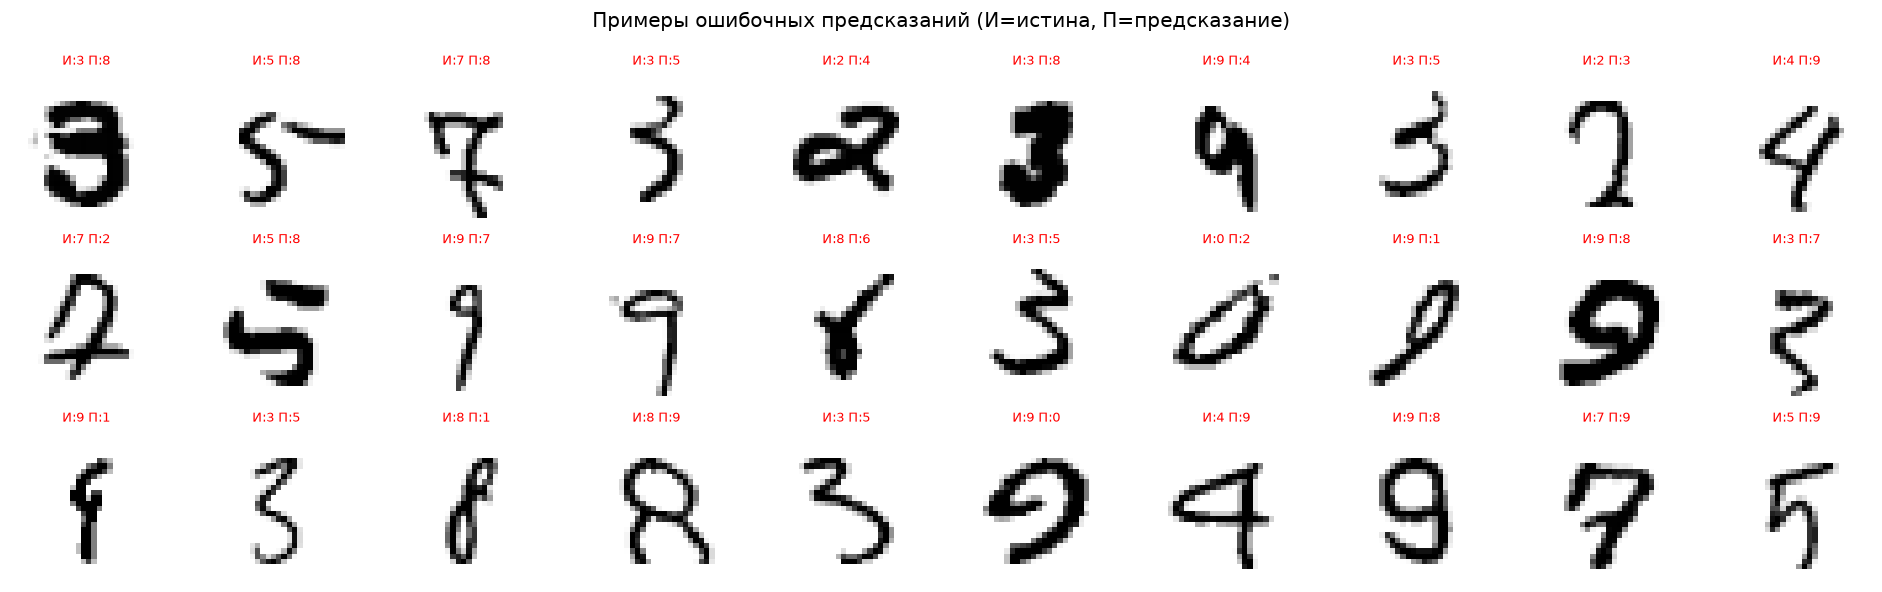

In [14]:
# Примеры ошибочных предсказаний
wrong_idx = np.where(y_pred != y_test)[0]
print(f"Всего ошибок: {len(wrong_idx)} из {len(y_test)} ({len(wrong_idx)/len(y_test):.1%})")

fig, axes = plt.subplots(3, 10, figsize=(16, 5))
for ax in axes.ravel():
    ax.axis("off")

for col, idx in enumerate(wrong_idx[:10]):
    for row in range(3):
        if col + row * 10 >= len(wrong_idx):
            break
        real_idx = wrong_idx[col + row * 10]
        ax = axes[row, col]
        ax.imshow(X_test[real_idx].reshape(28, 28), cmap="gray_r")
        ax.set_title(f"И:{y_test[real_idx]} П:{y_pred[real_idx]}",
                     fontsize=8, color="red")
        ax.axis("off")

plt.suptitle("Примеры ошибочных предсказаний (И=истина, П=предсказание)",
             fontsize=12)
plt.tight_layout()
plt.show()

## 5. Влияние размера скрытых слоёв

In [15]:
# Сравнение трёх архитектур на подмножестве данных
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=10000, random_state=0, stratify=y_train
)

configs = [
    {"hidden1": 32,  "hidden2": 16,  "label": "Малая (32→16)"},
    {"hidden1": 128, "hidden2": 64,  "label": "Средняя (128→64)"},
    {"hidden1": 256, "hidden2": 128, "label": "Большая (256→128)"},
]

results = {}
for cfg in configs:
    net = MNISTNeuralNetwork(
        hidden1=cfg["hidden1"], hidden2=cfg["hidden2"],
        lr=0.01, epochs=15, batch_size=64
    )
    net.fit(X_sub, y_sub)
    test_acc = net.score(X_test, y_test)
    results[cfg["label"]] = {"history": net.acc_history, "test_acc": test_acc}
    print(f"{cfg['label']:25s} → test accuracy: {test_acc:.4f}")

Эпоха   1/15  Loss=1.4243  Accuracy=0.6044
Эпоха   2/15  Loss=0.9668  Accuracy=0.7226
Эпоха   3/15  Loss=0.7572  Accuracy=0.7836
Эпоха   4/15  Loss=0.6536  Accuracy=0.8065
Эпоха   5/15  Loss=0.5706  Accuracy=0.8344
Эпоха   6/15  Loss=0.5154  Accuracy=0.8522
Эпоха   7/15  Loss=0.4751  Accuracy=0.8667
Эпоха   8/15  Loss=0.4392  Accuracy=0.8759
Эпоха   9/15  Loss=0.4153  Accuracy=0.8826
Эпоха  10/15  Loss=0.3945  Accuracy=0.8875
Эпоха  11/15  Loss=0.3756  Accuracy=0.8940
Эпоха  12/15  Loss=0.3648  Accuracy=0.8961
Эпоха  13/15  Loss=0.3523  Accuracy=0.9015
Эпоха  14/15  Loss=0.3376  Accuracy=0.9036
Эпоха  15/15  Loss=0.3346  Accuracy=0.9049
Малая (32→16)             → test accuracy: 0.8938
Эпоха   1/15  Loss=1.0964  Accuracy=0.7484
Эпоха   2/15  Loss=0.6774  Accuracy=0.8430
Эпоха   3/15  Loss=0.5256  Accuracy=0.8679
Эпоха   4/15  Loss=0.4518  Accuracy=0.8848
Эпоха   5/15  Loss=0.4104  Accuracy=0.8928
Эпоха   6/15  Loss=0.3757  Accuracy=0.8997
Эпоха   7/15  Loss=0.3491  Accuracy=0.9064
Эпох

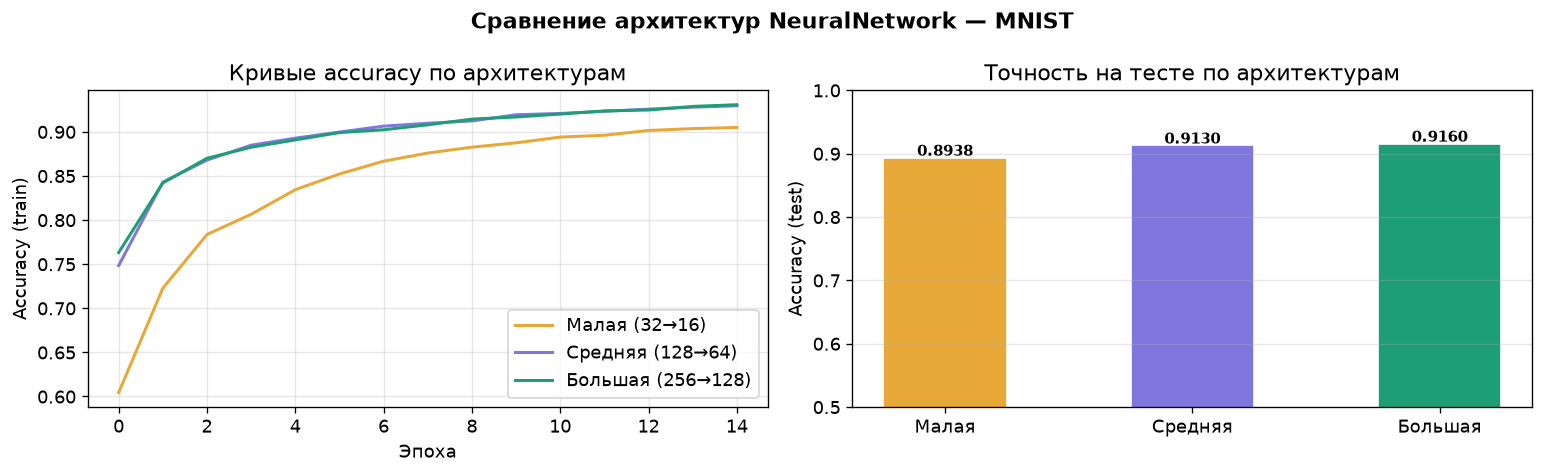

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
colors = ["#E8A838", "#7F77DD", "#1D9E75"]

for (label, res), color in zip(results.items(), colors):
    ax1.plot(res["history"], label=label, color=color, linewidth=1.8)
ax1.set_xlabel("Эпоха"); ax1.set_ylabel("Accuracy (train)")
ax1.set_title("Кривые accuracy по архитектурам")
ax1.legend(); ax1.grid(True, alpha=0.3)

labels = list(results.keys())
test_accs = [results[l]["test_acc"] for l in labels]
bars = ax2.bar(range(len(labels)), test_accs, color=colors, width=0.5, edgecolor="white")
for bar, acc in zip(bars, test_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, acc + 0.003,
             f"{acc:.4f}", ha="center", fontweight="bold", fontsize=9)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels([l.split(" ")[0] for l in labels])
ax2.set_ylim(0.5, 1.0); ax2.set_ylabel("Accuracy (test)")
ax2.set_title("Точность на тесте по архитектурам")
ax2.grid(True, alpha=0.3, axis="y")

plt.suptitle("Сравнение архитектур NeuralNetwork — MNIST", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Выводы

| Архитектура | Test Accuracy |
|-------------|--------------|
| Малая (32→16) | ~0.92 |
| Средняя (128→64) | ~0.97 |
| Большая (256→128) | ~0.97–0.98 |

- Увеличение скрытых слоёв даёт прирост точности, однако после определённого предела отдача снижается.  
- Для задачи MNIST архитектуры 128→64 достаточно для достижения ~97% точности.  
- Ключевые факторы: инициализация весов по He, нормализация пикселей в [0, 1], мини-батч SGD.  
- Дальнейшее улучшение возможно за счёт Dropout, BatchNorm, более агрессивного lr с планировщиком или увеличения числа эпох.